In [2]:
# Task : Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Task : Load Dataset


df = pd.read_excel(
    "heart_disease.xlsx",
    sheet_name="Heart_disease"
)

print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']


In [4]:
# Task : Display Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None


In [5]:
# Task : Statistical Summary

print(df.describe())

              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000


In [6]:
# Task : Check Missing Values

print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


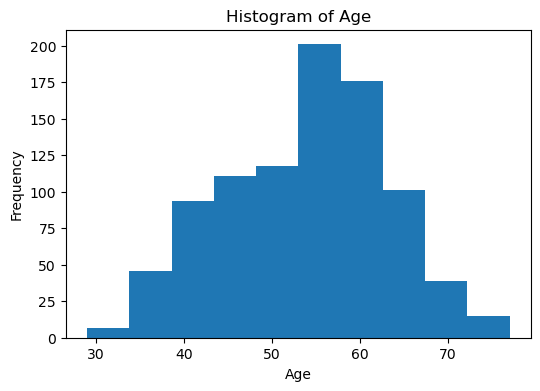

In [7]:
# Task : Histogram for Age

plt.figure(figsize=(6,4))

plt.hist(df['age'], bins=10)

plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

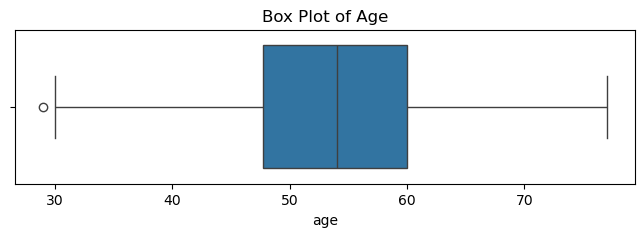

In [8]:
# Task : Box Plot for Age

plt.figure(figsize=(8,2))

sns.boxplot(x=df['age'])

plt.title("Box Plot of Age")

plt.show()

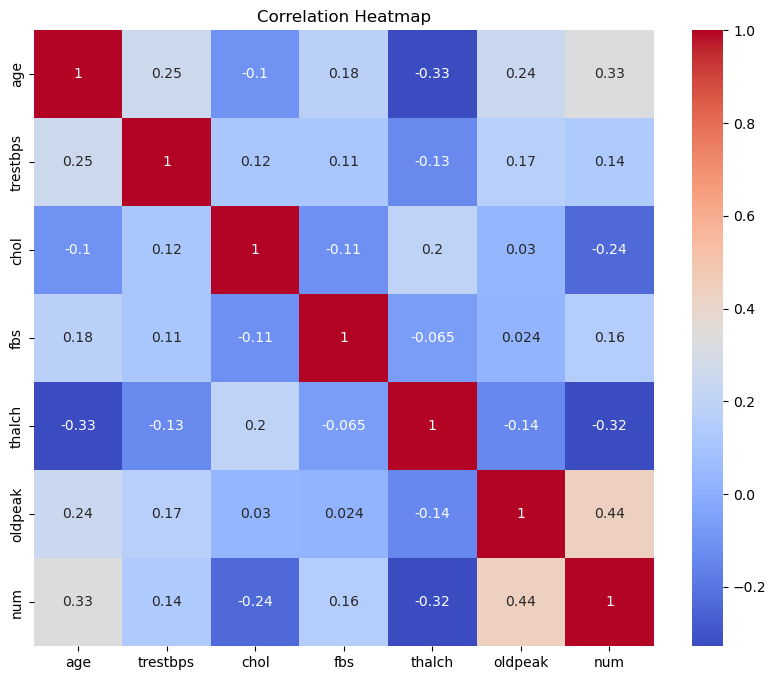

In [9]:
# Task: Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# Task : Clean Boolean Text Values

df = df.replace({
    'TRUE': 1,
    'FALSE': 0,
    'TURE': 1,
    'FLASE': 0,
    True: 1,
    False: 0
})

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

print(df.head())

   age   sex               cp  trestbps  chol  fbs         restecg  thalch  \
0   63  Male   typical angina       145   233    1  lv hypertrophy     150   
1   41  Male  atypical angina       135   203    0          normal     132   
2   57  Male     asymptomatic       140   192    0          normal     148   
3   52  Male   typical angina       118   186    0  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201    0          normal     126   

   exang  oldpeak        slope          thal  num  
0      0      2.3  downsloping  fixed defect    0  
1      0      0.0         flat  fixed defect    0  
2      0      0.4         flat  fixed defect    0  
3      0      0.0         flat  fixed defect    0  
4      1      1.5         flat  fixed defect    0  


C:\Users\AARYAN\AppData\Local\Temp\ipykernel_9156\3490778279.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({
C:\Users\AARYAN\AppData\Local\Temp\ipykernel_9156\3490778279.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [11]:
# Task : Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = ['sex', 'cp', 'restecg', 'slope', 'thal']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0     150      0      2.3      0   
1   41    1   1       135   203    0        1     132      0      0.0      1   
2   57    1   0       140   192    0        1     148      0      0.4      1   
3   52    1   3       118   186    0        0     190      0      0.0      1   
4   57    1   0       110   201    0        1     126      1      1.5      1   

   thal  num  
0     0    0  
1     0    0  
2     0    0  
3     0    0  
4     0    0  


In [12]:
# Task 10: Define Features and Target Variable

X = df.drop(columns=['num'])

y = df['num']

print(X.head())

print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0     150      0      2.3      0   
1   41    1   1       135   203    0        1     132      0      0.0      1   
2   57    1   0       140   192    0        1     148      0      0.4      1   
3   52    1   3       118   186    0        0     190      0      0.0      1   
4   57    1   0       110   201    0        1     126      1      1.5      1   

   thal  
0     0  
1     0  
2     0  
3     0  
4     0  
0    0
1    0
2    0
3    0
4    0
Name: num, dtype: int64


In [13]:
# Task : Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(726, 12)
(182, 12)


In [14]:
# Task : Train Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

print("Decision Tree Model Training Completed")

Decision Tree Model Training Completed


In [15]:
# Task : Predict Testing Data

y_pred = dt_model.predict(X_test)

print(y_pred[:10])

[1 1 0 4 1 0 1 0 1 1]


In [16]:
# Task : Evaluate Model Performance

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')

recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.5054945054945055
Precision: 0.5179902730322898
Recall: 0.5054945054945055
F1 Score: 0.5112702482644679


In [17]:
# Task : Hyperparameter Tuning

tuned_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=4,
    random_state=42
)

tuned_model.fit(X_train, y_train)

tuned_pred = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)

print("Tuned Model Accuracy:", tuned_accuracy)

Tuned Model Accuracy: 0.5604395604395604


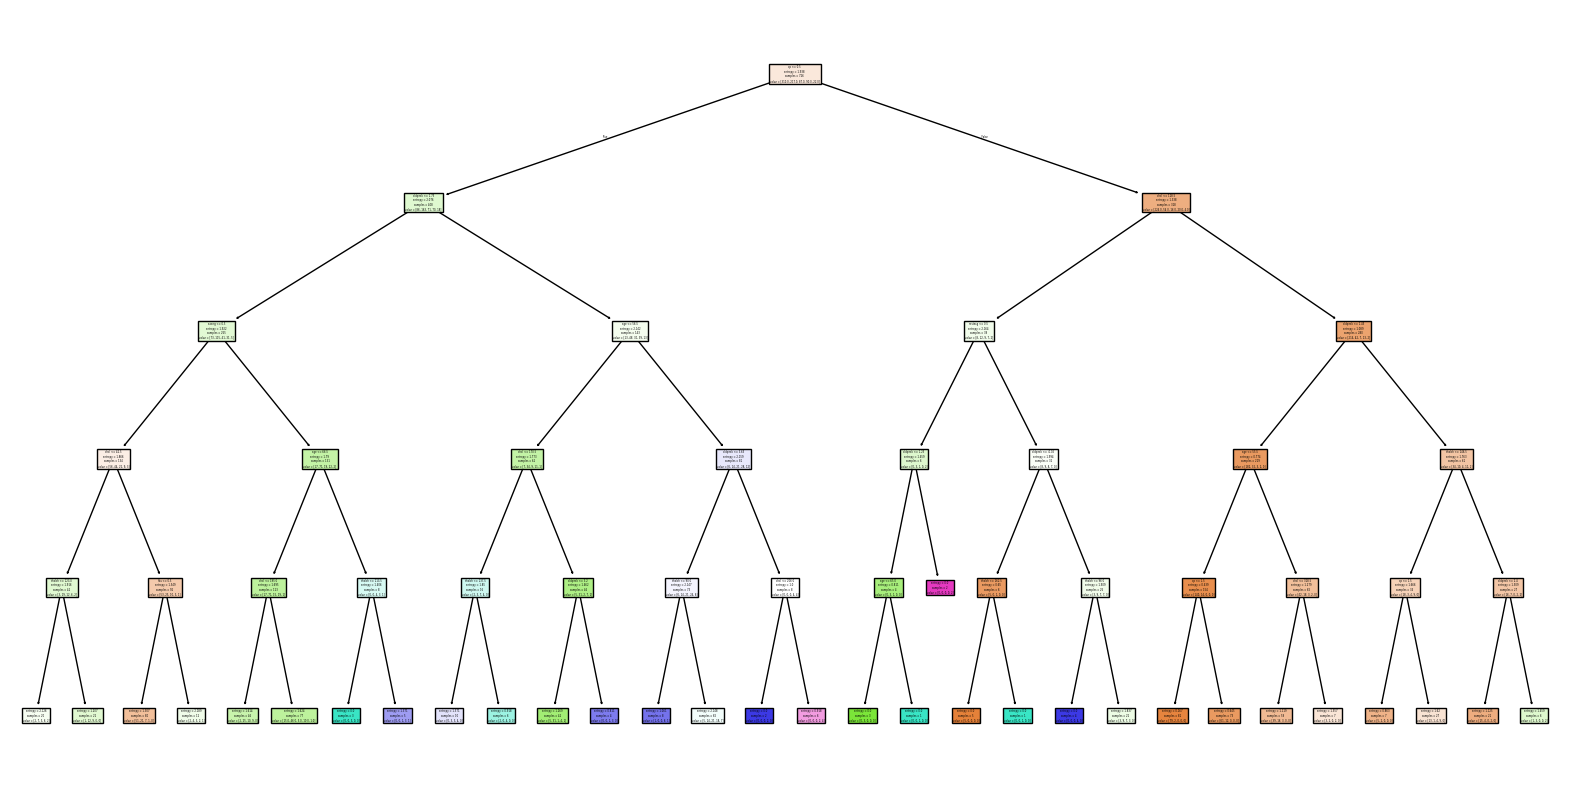

In [18]:
# Task : Visualize Decision Tree

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    tuned_model,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [19]:
# Task : Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

     Feature  Importance
2         cp    0.290580
9    oldpeak    0.204469
4       chol    0.191083
0        age    0.113647
7     thalch    0.109904
8      exang    0.048550
5        fbs    0.022876
6    restecg    0.018891
1        sex    0.000000
3   trestbps    0.000000
10     slope    0.000000
11      thal    0.000000


In [20]:
# Interview Question 1

print("Common hyperparameters in Decision Tree:")

print("1. max_depth")
print("2. min_samples_split")
print("3. criterion")

print("These hyperparameters control model complexity and overfitting.")

Common hyperparameters in Decision Tree:
1. max_depth
2. min_samples_split
3. criterion
These hyperparameters control model complexity and overfitting.


In [21]:
# Interview Question 2

print("Label Encoding converts categories into numerical labels.")

print("One-Hot Encoding creates separate binary columns for each category.")

print("One-Hot Encoding avoids ordinal relationship problems.")

Label Encoding converts categories into numerical labels.
One-Hot Encoding creates separate binary columns for each category.
One-Hot Encoding avoids ordinal relationship problems.


In [22]:
# Report
print("1. Data preprocessing completed successfully.")
print("2. Correlation analysis was performed.")
print("3. Model performance was evaluated.")
print("4. Results indicate useful patterns for prediction.")

1. Data preprocessing completed successfully.
2. Correlation analysis was performed.
3. Model performance was evaluated.
4. Results indicate useful patterns for prediction.
